# Bimetallic distributions: PDDF, RDF, LBL

# Pair Distance Distribution Function - PDDF

Given a nanoparticle, the system pair distance distribution function is defined as:

\begin{equation}
g(d) = \frac{1}{(N)(N - 1)} \sum_{i=1}^{N} \sum_{\substack{j=1 \\ j \ne i}}^{N} \delta'(r_{ij} - d)
\end{equation}

where $N$ is the number of atoms in the system, $r_{ij}$ is the distance between an atom $i$ and an atom $j$ and $d$ is the distance length probed, with $\varepsilon$ defining the width of the distance bin:

\begin{equation}
\delta' = 
\begin{cases}
1 & \text{if } d - \varepsilon \leq r_{ij} \leq d + \varepsilon, \\
0 & \text{otherwise}
\end{cases}
\end{equation}

$\varepsilon$ magnitude thus define whether two atomic distances are parsed into the same or different distance bins.

The PDDF provides rich structural information about the nanoparticle. In particular, the first minimum in $g(d)$ indicates the distance to define the first-neighbor shell, while the presence of sharp peaks reflects a high degree of structural order. 

Providing the element_A and element_B is it also possible to calculate the chemical PDDF.

# Radial Distance Distribution Function - RDF

The radial distribution function in a system of particles, describes how density varies as a function of distance from a reference particle. It is a measure of the probability of finding a particle at a distance of r away from a given reference particle, here the center of mass.

The density of atoms from the centre of mass of the whole nanoparticle ($\mathrm{CoM}_w$); the distribution of atoms-A from their centre of mass, $\mathrm{CoM}_A$; and similarly for B-atoms, from the $\mathrm{CoM}_B$.
The RDFs count the number of atoms falling in concentric shells from the centre of mass, of the nanoparticle:
\begin{equation}
r_{\alpha}(i \in w,A,B)=\sqrt{\left(\hat{x}_\alpha(i)\right)^2+\left(\hat{y}_\alpha(i)\right)^2+\left(\hat{z}_\alpha(i)\right)^2} .
\end{equation}
where the coordinates $w$ is referring to whole cluster, $\hat{x}_\alpha, \hat{y}_\alpha, \hat{z}_\alpha$ of the atom-i and chemical species $\alpha=A, B$ are re-scaled w.r.t the centre of mass chosen, $\mathrm{CoM}_w$, $\mathrm{CoM}_A$ or $\mathrm{CoM}_B$.


# Layer by Layer - LBL
During a LBL analysis, the nanoparticles is sliced into layers and binned of a certain height provided by the user.
A reasonable value to use can be the inter-layer distance of (111) planes in the bulk. 
The axis along which (perpendicular) planes are cut should be specified by the user.
Eventually, you can monitor the number of layers versus time, $m_{l}(t)$, and count the number of atoms per each chemical species $\alpha$ in each layer, $N_l^{\alpha}(t)$.  

In this notebook, we demonstrate how to import and analyze both **single-frame** and **multi-frame XYZ files**. For each case, we compute the pair distance 
distribution function (PDDF) in both lattice units and Ångström (Å), and the radial distribution function (RDF).

All analyses in this notebook focus on **bimetallic nanoalloyes**.
With respect to the "monometallic distribution Jupyter notebook," fewer examples will be displayed here. Users can easily add more by using the print() function.

### Notebook Structure

1. Setup
- Import the required libraries  
- Define the absolute working path  
- Adjust Jupyter display settings for improved output readability  


2. Single-Frame Analysis
- 2.1 Define input parameters and file paths  
- 2.2 Read the XYZ file  
- 2.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 2.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 2.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  


3. Multi-Frame Analysis
- 3.1 Define input parameters and file paths  
- 3.2 Read the XYZ file  
- 3.3 Compute the PDDF in lattice units and visualize it (line plot and histogram)  
- 3.4 Compute the PDDF in Å and visualize it (line plot and histogram)  
- 3.5 Compute the radial distribution function (RDF) relative to the center of mass and plot it  

## Set the stage

In [1]:
# import snow libraries
from snow.io.xyz import *
from snow.descriptors.distributions import *

In [2]:
# import other required-useful libraries

import numpy as np
# set a continuous printoption for the print in a jupyter-notebook
np.set_printoptions(threshold=np.inf)

import matplotlib.pyplot as plt #to plot
xfig=4
yfig=3

In [3]:
# check your absolute path and save in a variable
absolute_path = ! pwd
absolute_path = absolute_path[0]
absolute_path

'/Users/sofiazinzani/Documents/Dottorato/Unimi/Codici/pySNOW/tutorial'

# Let's begin - Single frame xyz file

In [4]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="Au52Rh19.xyz"


element_A='Au'
element_B='Rh'

my_lattice_A=4.079
my_lattice_B=3.084
my_lattice_mean=(my_lattice_A+my_lattice_B)/2


**!** take care about what lattice you would like to use in the following functions: the choice of the lattice is fundamental and will change a lot your results

In [5]:
# Here the code read the xyz file
el, coords= read_xyz(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=len(coords)
print(nframe)

71


## PDDF in \AA

### Global PDDF in \AA

In [6]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_mean

pddf = pddf_calculator(coords, bin_width = my_bin_size_aa, use_lattice_units=False)

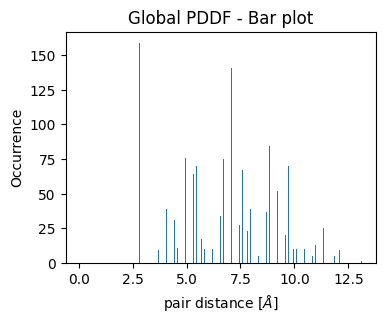

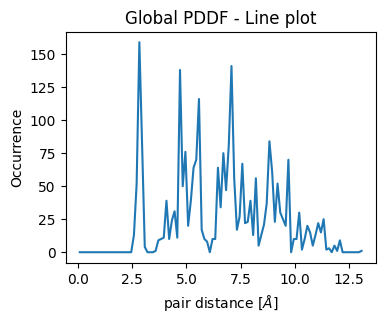

In [7]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("Global PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("Global PDDF - Line plot")
plt.show()

### Chemical PDDF in \AA

In [8]:
# For A–A pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_A = my_bin_size_lattice*my_lattice_A

pddf = pddf_calculator_by_elements(el, coords, [element_A, element_A], bin_width = my_bin_size_aa_A, use_lattice_units=False)

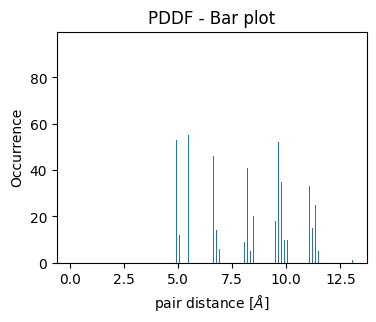

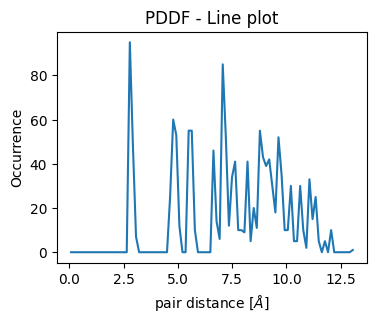

In [9]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

In [10]:
# For B–B pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_B = my_bin_size_lattice*my_lattice_B

pddf = pddf_calculator_by_elements(el, coords, [element_B, element_B], bin_width = my_bin_size_aa_B, use_lattice_units=False)


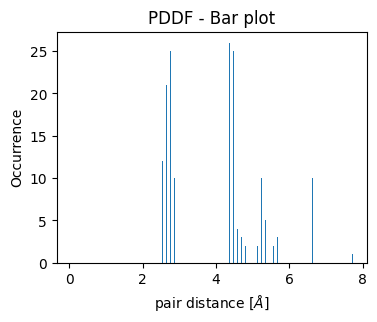

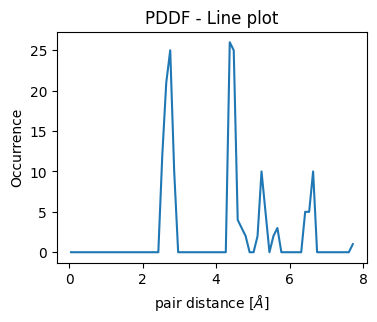

In [11]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

In [12]:
#For A–B pairs
my_bin_size_lattice = 0.035
my_bin_size_aa_AB = my_bin_size_lattice*my_lattice_mean

pddf = pddf_calculator_by_elements(el, coords, [element_A, element_B], bin_width = my_bin_size_aa_AB, use_lattice_units=False)

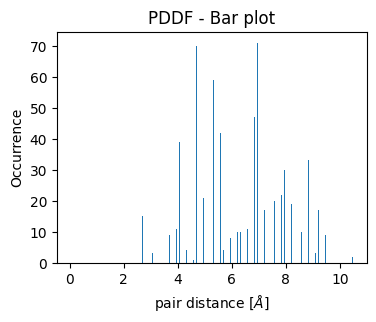

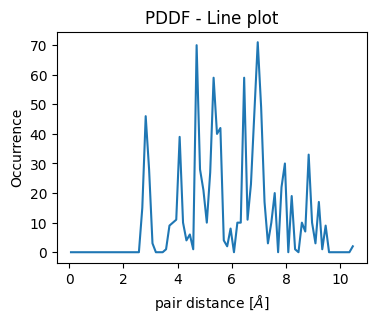

In [13]:
plt.figure(figsize=(xfig, yfig))
plt.bar(pddf[0], pddf[1], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(pddf[0], pddf[1])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

## RDF

In [14]:
# split coords and el depending on the chemical species
coords_A = []
el_A = []
coords_B = []
el_B = []

for i in range(len(el)):
    if el[i] == element_A:
        coords_A.append(coords[i])
        el_A.append(el[i])

    elif el[i] == element_B:
        coords_B.append(coords[i])
        el_B.append(el[i])

    else:
        print("error: the elements provided does not match with your file")

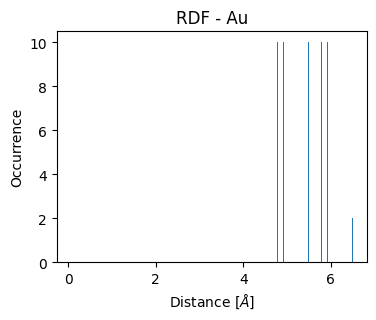

In [15]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_A

#com_rdf = com_rdf_calculator(coords, elements=el, bin_width = my_bin_size_aa)
com_rdf_A = com_rdf_calculator(coords_A, bin_width = my_bin_size_aa, elements=el_A)

plt.figure(figsize=(xfig, yfig))
plt.bar(com_rdf_A[0], com_rdf_A[1], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - "+element_A)
plt.show()

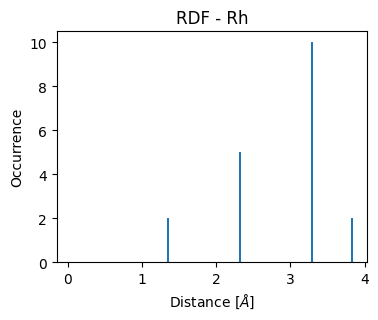

In [16]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_B

#com_rdf = com_rdf_calculator(coords, elements=el, bin_width = my_bin_size_aa)
com_rdf_B = com_rdf_calculator(coords_B, bin_width = my_bin_size_aa, elements=el_B)

plt.figure(figsize=(xfig, yfig))
plt.bar(com_rdf_B[0], com_rdf_B[1], width=0.02)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - "+element_B)
plt.show()

## LBL

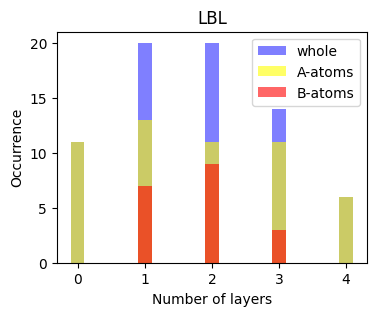

In [17]:

layer_height= my_lattice_A/ (np.sqrt(3)) #choose carefully considering that you have two different heights, how to combine them or which one you choose.

n_layers, n_atoms_layer, n_atoms_layer_A, n_atoms_layer_B = cut_layers(el, coords, layer_height, 'z', element_A, element_B)

plt.figure(figsize=(xfig, yfig))
plt.bar(n_layers, n_atoms_layer, width=0.2, color='blue', alpha=0.5, label='whole')
plt.bar(n_layers, n_atoms_layer_A, width=0.2, color='yellow', alpha=0.6, label='A-atoms')
plt.bar(n_layers, n_atoms_layer_B, width=0.2, color='red', alpha=0.6, label='B-atoms')
plt.xlabel("Number of layers")
plt.ylabel("Occurrence")
plt.title("LBL")
plt.legend()
plt.show()

# Let's begin - Multiple frame xyz file

In [18]:
# Here you have to define: (1) the path where your stucture is. (2) the name of the file you want to analyse. (3) the lattice of the chemical specie.
path_file="tutorial_structures"
file="movie-separated.xyz"

element_A='Au'
element_B='Pt'

my_lattice_A=4.079
my_lattice_B=3.92
my_lattice_mean=(my_lattice_A+my_lattice_B)/2

In [19]:
# Here the code read the xyz file
el, coords= read_xyz_movie(absolute_path + '/' + path_file + '/' + file)

# check the number of frame and save on a variable
nframe=len(coords)
print(nframe)

2309


## PDDF in \AA

### Global PDDF in \AA

In [20]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator(coords[t], bin_width = my_bin_size_aa, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

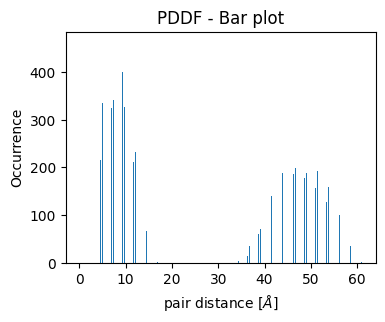

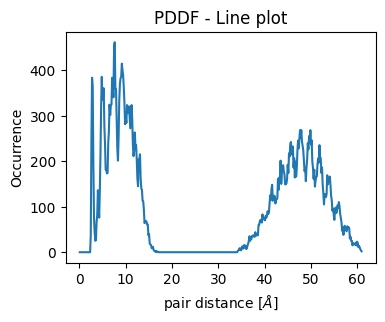

In [21]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

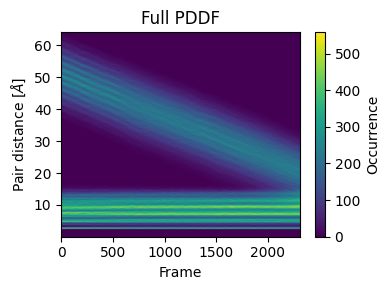

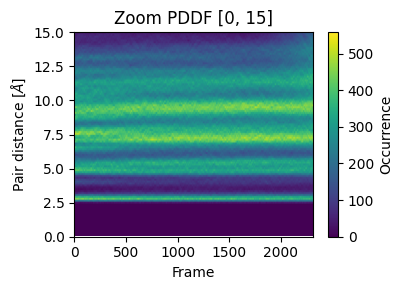

In [22]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("Full PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For A-A pairs

In [23]:
my_bin_size_lattice = 0.035
my_bin_size_aa_A = my_bin_size_lattice*my_lattice_A

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(el[t], coords[t], [element_A, element_A], bin_width = my_bin_size_aa_A, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

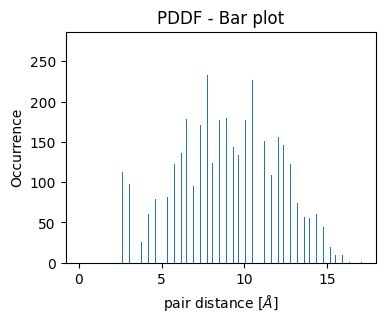

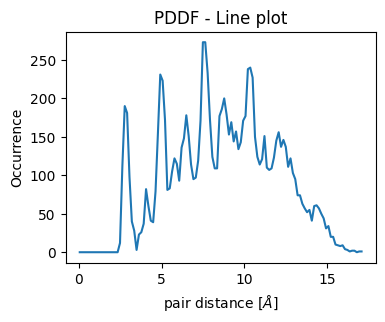

In [24]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

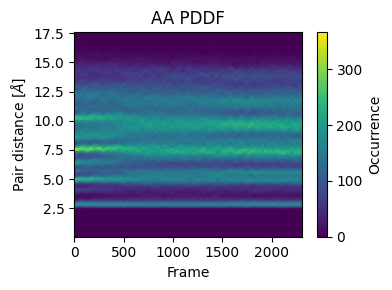

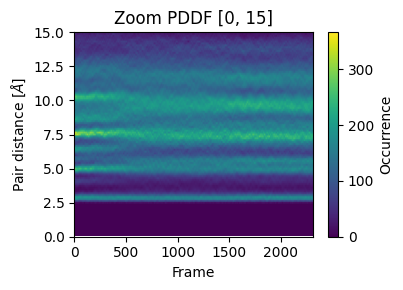

In [25]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("AA PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For B-B pairs

In [26]:
my_bin_size_lattice = 0.035
my_bin_size_aa_B = my_bin_size_lattice*my_lattice_B

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(el[t], coords[t], [element_B, element_B], bin_width = my_bin_size_aa_B, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

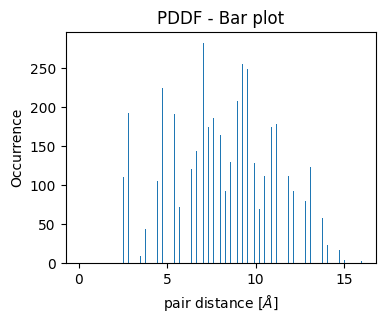

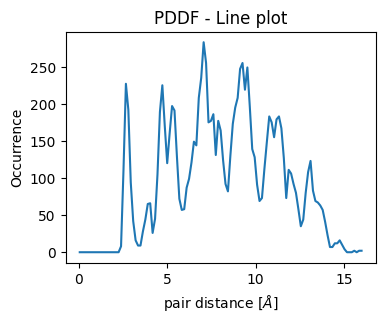

In [27]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

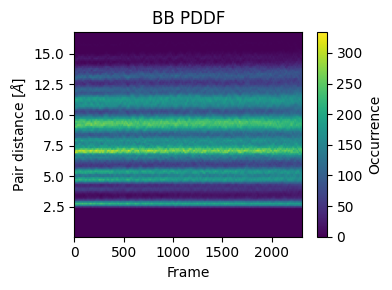

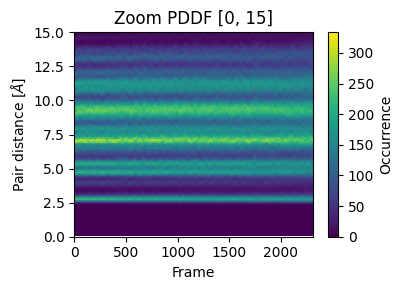

In [28]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("BB PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

### Chemical PDDF in \AA - For A-B pairs

In [ ]:
my_bin_size_lattice = 0.035
my_bin_size_aa_AB = my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    pddf = pddf_calculator_by_elements(el[t], coords[t], [element_A, element_B], bin_width = my_bin_size_aa_AB, use_lattice_units=False)
    bins_list.append(pddf[0])
    occ_list.append(pddf[1])

#### Plot one frame

In [ ]:
t=190 # choose the frame to plot

plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.02)
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Bar plot")
plt.show()

plt.figure(figsize=(xfig, yfig))
plt.plot(bins_list[t], occ_list[t])
plt.xlabel("pair distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("PDDF - Line plot")
plt.show()

#### Plot multiple frames

In [ ]:
# Create a common grid for different possible lenght of PDDF at different frames

nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


# usa bin size in Å !!!
r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)



# First plot: full range
plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis'
)
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("AB PDDF")
plt.tight_layout()
plt.show()


# Second plot: zoom with a mask and new color scale
ymin, ymax = 0, 15

rows = np.where((r_common >= ymin) & (r_common <= ymax))[0]

H_masked = H.T[rows, :]
vmin = H_masked.min()
vmax = H_masked.max()



plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)

plt.ylim([ymin, ymax])
plt.xlabel("Frame")
plt.ylabel("Pair distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title(f"Zoom PDDF [{ymin}, {ymax}]")
plt.tight_layout()
plt.show()

## RDF

### Global RDF

In [ ]:
my_bin_size_lattice = 0.035
my_bin_size_aa= my_bin_size_lattice*my_lattice_mean

bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf = com_rdf_calculator(coords[t], bin_width = my_bin_size_aa, elements= el[t])

    bins_list.append(com_rdf[0])
    occ_list.append(com_rdf[1])

t=20
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

### Chemical RDF 

In [ ]:
### ARRIVATA QUI


# split coords and el depending on the chemical species

coords_A_list = []
el_A_list = []
coords_B_list = []
el_B_list = []

#for t in range(nframe):
for el_t, coords_t in zip(el, coords):

    coords_A = []
    el_A = []
    coords_B = []
    el_B = []


    #coords_t = coords[t]
    #el_t = el[t]

    for e, coord in zip(el_t, coords_t):
        if e == element_A:
            coords_A.append(coord)
            el_A.append(e)
        elif e == element_B:
            coords_B.append(coord)
            el_B.append(e)
        else:
            print(f"Error: element {e} does not match {element_A} or {element_B}")

    coords_A_list.append(coords_A)
    coords_B_list.append(coords_B)
    el_A_list.append(el_A)
    el_B_list.append(el_B)



In [ ]:
from snow.descriptors.shape_descriptors import *
print(center_of_mass(el[0], coords[0]))
print(center_of_mass(el_A_list[0], coords_A_list[0]))
print(center_of_mass(el_B_list[0], coords_B_list[0]))

#### Chemical RDF - Element A

In [ ]:


my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_A


bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf_A = com_rdf_calculator(coords_A_list[t], elements=el_A_list[t], bin_width = my_bin_size_aa)
    bins_list.append(com_rdf_A[0])
    occ_list.append(com_rdf_A[1])


t=200
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()


print(np.sum(occ_list[0]))

#### Chemical RDF - Element B

In [ ]:
my_bin_size_lattice = 0.035
my_bin_size_aa = my_bin_size_lattice*my_lattice_B


bins_list = []
occ_list = []

for t in range(nframe):
    com_rdf_B = com_rdf_calculator(coords_B_list[t], elements=el_B_list[t], bin_width = my_bin_size_aa)
    bins_list.append(com_rdf_B[0])
    occ_list.append(com_rdf_B[1])

t=200
plt.figure(figsize=(xfig, yfig))
plt.bar(bins_list[t], occ_list[t], width=0.05)
plt.xlabel("Distance [$\\AA$]")
plt.ylabel("Occurrence")
plt.title("RDF - Bar plot")
plt.show()

print(np.sum(occ_list[0]))

In [ ]:
# Create a common grid for different possible lenght of RDF at different frames
nbins_max = max(len(r) for r in bins_list)
r_max = max(r[-1] for r in bins_list)


r_common = np.arange(
    bins_list[0][0],
    r_max + my_bin_size_aa,
    my_bin_size_aa
)

nbins_common = len(r_common)

H = np.zeros((nframe, nbins_common))

for t in range(nframe):
    r = bins_list[t]
    occ = occ_list[t]

    # interpolazione
    H[t] = np.interp(r_common, r, occ, left=0, right=0)


plt.figure(figsize=(xfig, yfig))
im = plt.imshow(
    H.T,
    aspect='auto',
    origin='lower',
    extent=[0, nframe-1, r_common[0], r_common[-1]],
    cmap='coolwarm'
)
plt.xlabel("Frame")
plt.ylabel("Distance [$\\AA$]")
plt.colorbar(im, label="Occurrence")
plt.title("RDF Element B")
plt.tight_layout()
plt.show()
